<a href="https://colab.research.google.com/github/2025ae05285-art/Assignment/blob/main/CS_Assignment2_2025AE05285.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**
AI & ML Techniques for Cyber Security - Assignment-02: Intrusion Detection using Machine Learning Models
**

**STUDENT INFORMATION **

BITS ID: [2025AE05285]

Name: [SHABA JOSEPH]

Email: [2025ae05285@wilp.bits-pilani.ac.in
]

Date: [28-APR-2026]


## 1. Overall Solution Design and Process Architecture

**Data Collection:** Gather network traffic data from the KDD Cup
intrusion dataset.

**Preprocessing:** Clean data, encode categorical features, remove unnecessary columns, and scale features.

**Train-Test Split:** Divide dataset into training and testing sets.

**Model Training:** Train machine learning classifiers such as Random Forest, SVM, Logistic Regression, etc.

**Intrusion Detection:** Use the trained model to classify network traffic as normal or attack.

**Alert Generation:** Raise alerts when malicious/intrusion traffic is detected.

An intrusion detection system using machine learning works by collecting network traffic data, preprocessing it through cleaning and feature scaling, splitting it into training and testing datasets, training machine learning models on the processed data, and then using the trained model to classify incoming traffic as normal or malicious, generating alerts whenever an intrusion is detected.

Various Algorithms Applied: Gaussian Naive Bayes, Decision Tree, Random Forest, Support Vector Machine, Logistic Regression.

Approach Used: I have applied various classification algorithms that are mentioned above on the KDD dataset and compare there results to build a predictive model

**2. Tools Used and Reasons for Using Them:**
The intrusion detection system uses Python as the programming language because it is simple and widely used for machine learning development. Pandas and NumPy are used for data preprocessing and numerical operations on the dataset. Matplotlib and Seaborn help visualize the data and feature correlations. Scikit-learn is used to implement machine learning algorithms such as Random Forest, SVM, Logistic Regression, and Decision Tree for intrusion classification because it provides efficient built-in ML models and preprocessing tools

**Environment Setup and Library Imports**

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
!pip install --upgrade kaggle

In [ ]:
!
!ls -F

sample_data/


In [ ]:
# Download the dataset
# The dataset URL is: https://www.kaggle.com/datasets/kavl31/kdd-cup-1999-data
# The command to download is `kaggle datasets download <owner>/<dataset-name>`
!kaggle datasets download -d kavl31/kdd-cup-1999-data

# Unzip the dataset files, using -o to overwrite without prompting
!unzip -o kdd-cup-1999-data.zip -d .

Dataset URL: https://www.kaggle.com/datasets/kavl31/kdd-cup-1999-data
License(s): CC-BY-NC-SA-4.0
100% 154M/154M [00:01<00:00, 124MB/s]

Archive:  kdd-cup-1999-data.zip
  inflating: ./LICENSE               
  inflating: ./README.md             
  inflating: ./all_attack_types.txt  
  inflating: ./binary_classification/binary_classification/cleaned/full_binary_cleaned.csv  
  inflating: ./binary_classification/binary_classification/cleaned/test_binary_cleaned.csv  
  inflating: ./binary_classification/binary_classification/cleaned/train_binary_cleaned.csv  
  inflating: ./binary_classification/binary_classification/raw/full_binary.csv  
  inflating: ./binary_classification/binary_classification/raw/test_binary.csv  
  inflating: ./binary_classification/binary_classification/raw/train_binary.csv  
  inflating: ./full_multiclass/full_multiclass/cleaned/full_cleaned.csv  
  inflating: ./full_multiclass/full_multiclass/cleaned/test_cleaned.csv  
  inflating: ./full_multiclass/full_multiclas

2. Loading Dataset and Feature Names

In [ ]:
cols ="""duration,
protocol_type,
service,
flag,
src_bytes,
dst_bytes,
land,
wrong_fragment,
urgent,
hot,
num_failed_logins,
logged_in,
num_compromised,
root_shell,
su_attempted,
num_root,
num_file_creations,
num_shells,
num_access_files,
num_outbound_cmds,
is_host_login,
is_guest_login,
count,
srv_count,
serror_rate,
srv_serror_rate,
rerror_rate,
srv_rerror_rate,
same_srv_rate,
diff_srv_rate,
srv_diff_host_rate,
dst_host_count,
dst_host_srv_count,
dst_host_same_srv_rate,
dst_host_diff_srv_rate,
dst_host_same_src_port_rate,
dst_host_srv_diff_host_rate,
dst_host_serror_rate,
dst_host_srv_serror_rate,
dst_host_rerror_rate,
dst_host_srv_rerror_rate"""

columns =[]
for c in cols.split(',\n'):
    if(c.strip()):
       columns.append(c.strip())

columns.append('target')
print(len(columns))

42


Mapping Attack Categories

In [ ]:
attacks_types = {
    'normal': 'normal',
'back': 'dos',
'buffer_overflow': 'u2r',
'ftp_write': 'r2l',
'guess_passwd': 'r2l',
'imap': 'r2l',
'ipsweep': 'probe',
'land': 'dos',
'loadmodule': 'u2r',
'multihop': 'r2l',
'neptune': 'dos',
'nmap': 'probe',
'perl': 'u2r',
'phf': 'r2l',
'pod': 'dos',
'portsweep': 'probe',
'rootkit': 'u2r',
'satan': 'probe',
'smurf': 'dos',
'spy': 'r2l',
'teardrop': 'dos',
'warezclient': 'r2l',
'warezmaster': 'r2l',
'connection_typ': 'normal' # Added to handle KeyError
}

Data Exploration

In [ ]:
# Using the full_multiclass/full_multiclass/raw/full.csv from the downloaded dataset
path = "./full_multiclass/full_multiclass/raw/full.csv"
df = pd.read_csv(path, names = columns, header=0) # Added header=0 to skip the header row

# Adding Attack Type column
df['Attack Type'] = df.target.apply(lambda r:attacks_types[r])
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type
0,0,tcp,http,SF,215,45076,0,0,0,0,...,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,normal,normal
1,0,tcp,http,SF,162,4528,0,0,0,0,...,1.0,0.0,1.00,0.0,0.0,0.0,0.0,0.0,normal,normal
2,0,tcp,http,SF,236,1228,0,0,0,0,...,1.0,0.0,0.50,0.0,0.0,0.0,0.0,0.0,normal,normal
3,0,tcp,http,SF,233,2032,0,0,0,0,...,1.0,0.0,0.33,0.0,0.0,0.0,0.0,0.0,normal,normal
4,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,normal,normal


In [ ]:
df.shape

(4898431, 43)

In [ ]:
df.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


Data Preprocessing

In [ ]:
num_cols = df._get_numeric_data().columns

cate_cols = list(set(df.columns)-set(num_cols))
cate_cols.remove('target')
cate_cols.remove('Attack Type')

cate_cols

['protocol_type', 'service', 'flag']

In [ ]:
def bar_graph(feature, color=None):
    df[feature].value_counts().plot(kind="bar", color=color)

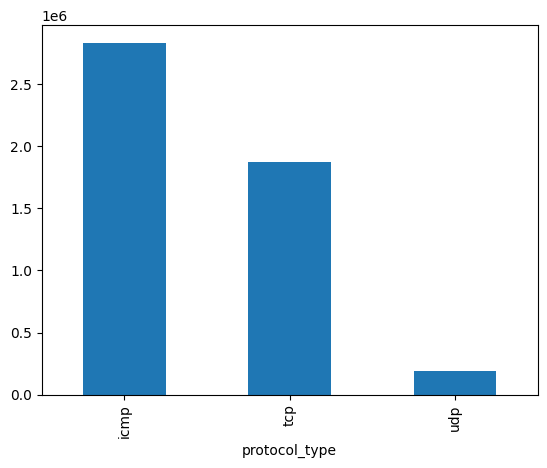

In [ ]:
bar_graph('protocol_type')

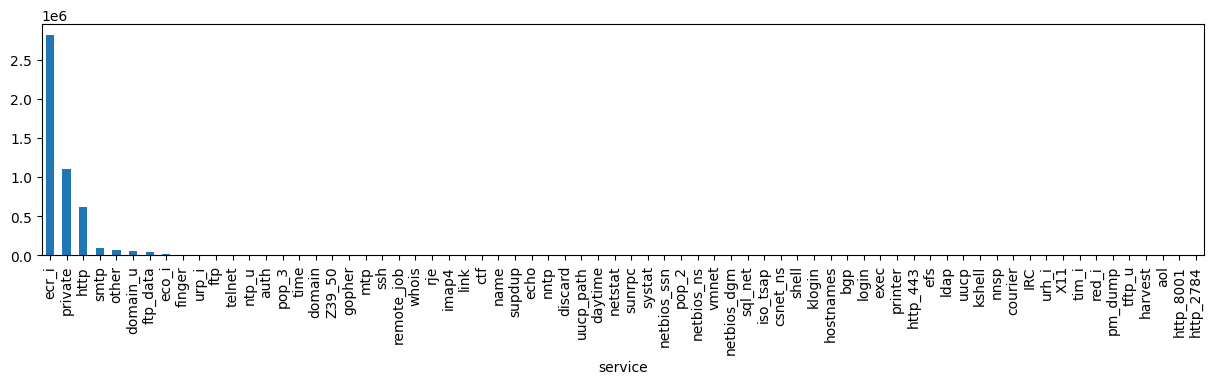

In [ ]:
plt.figure(figsize=(15,3))
bar_graph('service')

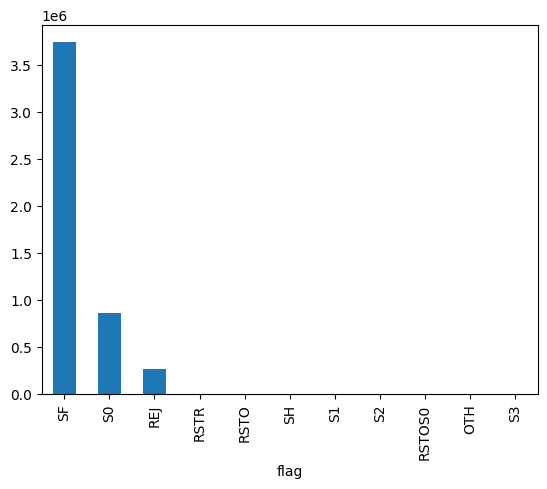

In [ ]:
bar_graph('flag')

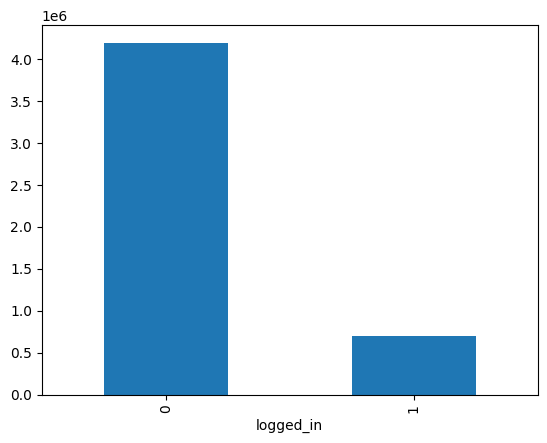

In [ ]:
bar_graph('logged_in')

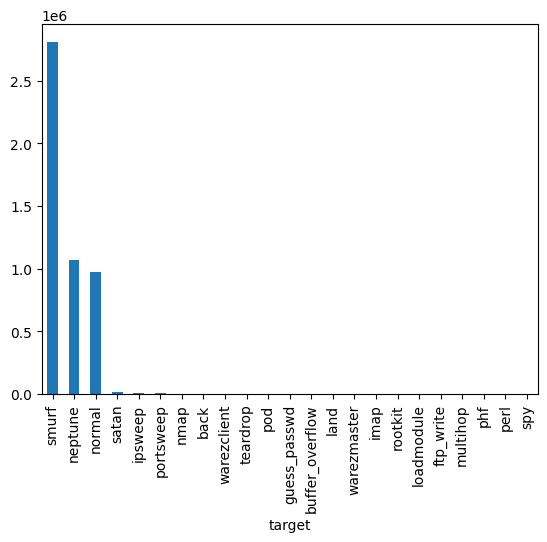

In [ ]:
bar_graph('target')

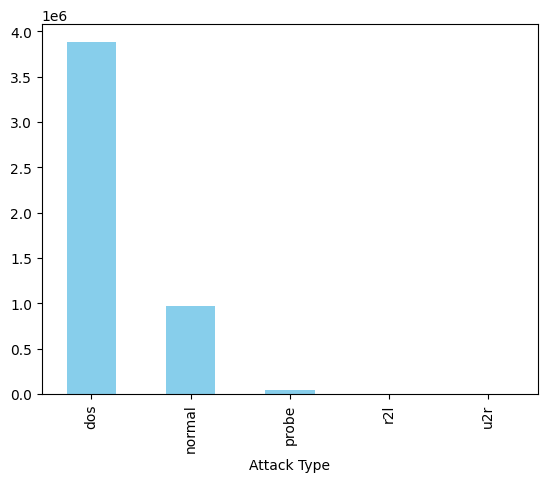

In [ ]:
bar_graph('Attack Type', color='skyblue')

In [ ]:
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'target', 'Attack Type'],
      dtype='object')

In [ ]:
df = df.drop(['target'], axis=1)

In [ ]:
df = df.dropna(axis='columns')

In [ ]:
ndf = df[[col for col in df.columns if df[col].nunique() > 1 and pd.api.types.is_numeric_dtype(df[col])]]

Splitting the Dataset

In [ ]:
y = df[['Attack Type']]
X = df.drop(['Attack Type'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(f"Shape of X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}, y_test: {y_test.shape}")

Shape of X_train: (3281948, 41), X_test: (1616483, 41)
Shape of y_train: (3281948, 1), y_test: (1616483, 1)


In [ ]:
pmap = {'icmp': 0, 'tcp': 1, 'udp': 2}
X_train['protocol_type'] = X_train['protocol_type'].map(pmap)
X_test['protocol_type'] = X_test['protocol_type'].map(pmap)

In [ ]:
fmap = {'SF': 0, 'S0': 1, 'REJ': 2, 'RSTR': 3, 'RSTO': 4, 'SH': 5, 'S1': 6, 'S2': 7, 'RSTOS0': 8, 'S3': 9, 'OTH': 10}
X_train['flag'] = X_train['flag'].map(fmap)
X_test['flag'] = X_test['flag'].map(fmap)

In [ ]:
X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])

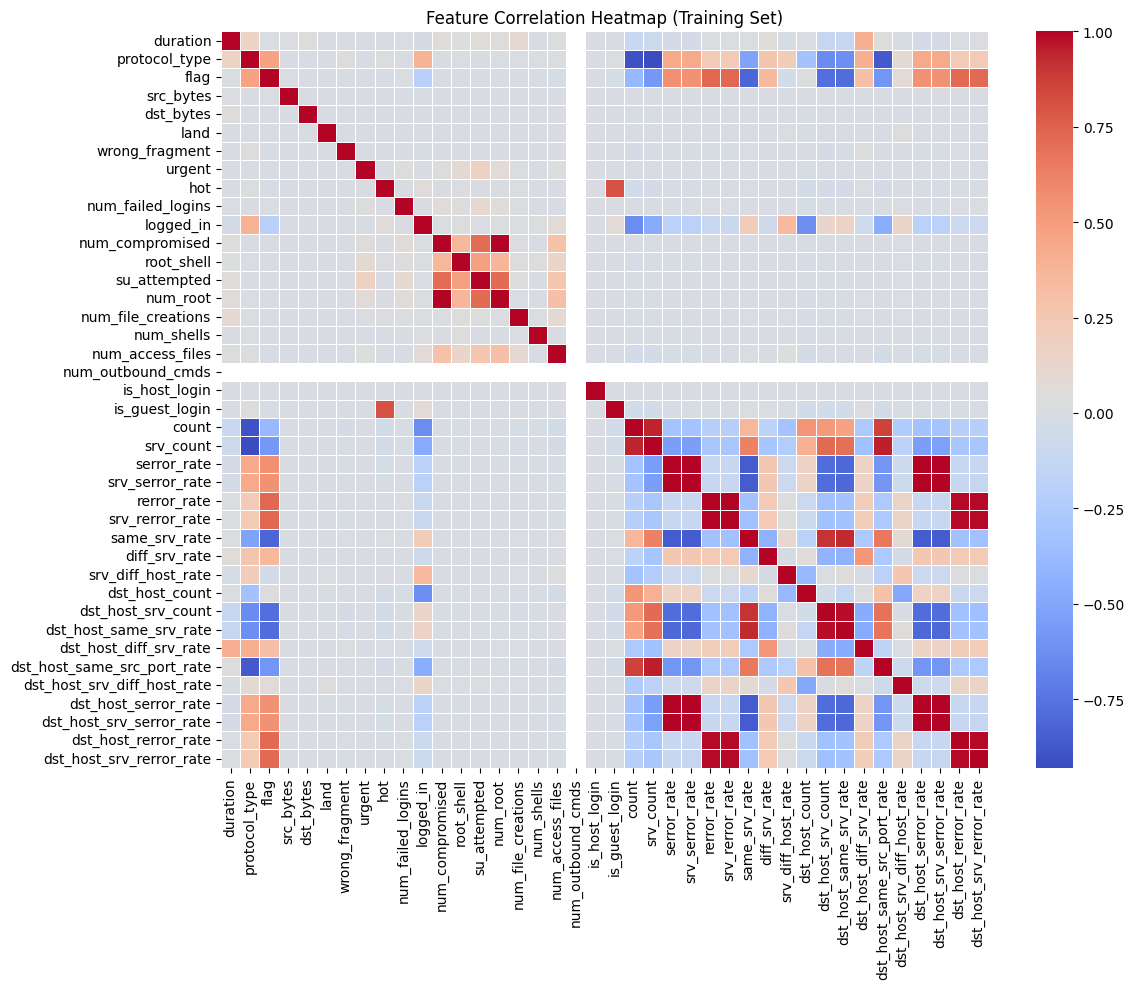

In [ ]:
corr = X_train_numeric.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap (Training Set)')
plt.tight_layout()
plt.show()

In [ ]:
highly_correlated = ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_srv_serror_rate',
                     'dst_host_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
                     'dst_host_same_srv_rate']

In [ ]:
X_train.drop(columns=highly_correlated, axis=1, inplace=True)
X_test.drop(columns=highly_correlated, axis=1, inplace=True)

In [ ]:
print(X_train[['is_host_login', 'num_outbound_cmds']].nunique())

is_host_login        2
num_outbound_cmds    1
dtype: int64


In [ ]:
X_train.drop(['is_host_login', 'num_outbound_cmds'], axis=1, inplace=True)
X_test.drop(['is_host_login', 'num_outbound_cmds'], axis=1, inplace=True)

In [ ]:
print(f"Shape of X_train after dropping correlated columns: {X_train.shape}")
print(f"Shape of X_test after dropping correlated columns: {X_test.shape}")

Shape of X_train after dropping correlated columns: (3281948, 31)
Shape of X_test after dropping correlated columns: (1616483, 31)


In [ ]:
X_train.drop('service', axis=1, inplace=True)
X_test.drop('service', axis=1, inplace=True)

In [ ]:
X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])

Feature Encoding

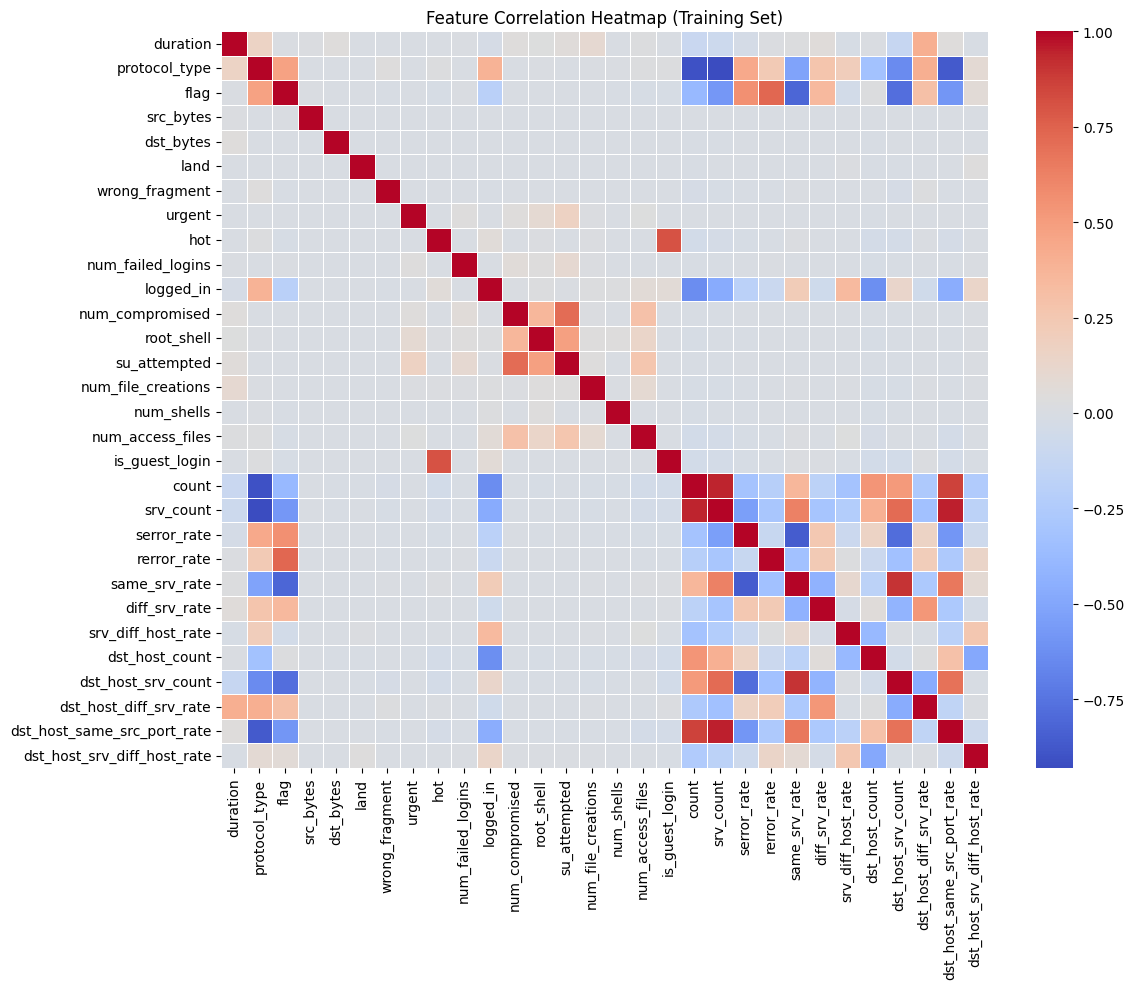

In [ ]:
corr = X_train_numeric.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap (Training Set)')
plt.tight_layout()
plt.show()

In [ ]:
X_train.head(5)

,duration,protocol_type,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,...,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate
4556539,0,1,0,308,3090,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,255,255,0.00,0.00,0.00
1023619,1,1,0,995,334,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,128,154,0.05,0.01,0.01
2863644,0,0,0,1032,0,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,255,255,0.00,1.00,0.00
2050987,0,0,0,1032,0,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,255,255,0.00,1.00,0.00
3436970,9,2,0,105,146,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,255,243,0.01,0.01,0.00


Data Scaling

In [ ]:
sc = MinMaxScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print(f"Shape of X_train after scaling: {X_train.shape}")
print(f"Shape of X_test after scaling: {X_test.shape}")

Shape of X_train after scaling: (3281948, 30)
Shape of X_test after scaling: (1616483, 30)


### Modelling

In [ ]:
models = {

}

# Initialize classifiers
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(criterion="entropy", max_depth=4),
    "Random Forest": RandomForestClassifier(n_estimators=30),
    "SVM": LinearSVC(max_iter=10000), # Changed to LinearSVC for speed, increased max_iter for convergence
    "Logistic Regression": LogisticRegression(max_iter=1200000),
    "Gradient Boosting": GradientBoostingClassifier(random_state=0),
}

In [ ]:
train_scores = []
test_scores = []
train_times = []
test_times = []

In [ ]:
for name, model in models.items():
    print(f"\nTraining {name}...")
    start = time.time()
    model.fit(X_train, y_train.values.ravel())
    end = time.time()
    train_time = end - start

    start = time.time()
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    end = time.time()
    test_time = end - start

    train_score = accuracy_score(y_train, y_pred_train) * 100
    test_score = accuracy_score(y_test, y_pred_test) * 100

    train_scores.append(train_score)
    test_scores.append(test_score)
    train_times.append(train_time)
    test_times.append(test_time)

    print(f"{name} - Train Accuracy: {train_score:.2f}%, Test Accuracy: {test_score:.2f}%")
    print(f"Training Time: {train_time:.4f}s, Testing Time: {test_time:.4f}s")


Training Naive Bayes...
Naive Bayes - Train Accuracy: 92.73%, Test Accuracy: 92.69%
Training Time: 4.3867s, Testing Time: 4.3902s

Training Decision Tree...
Decision Tree - Train Accuracy: 99.69%, Test Accuracy: 99.69%
Training Time: 12.4508s, Testing Time: 0.3678s

Training Random Forest...
Random Forest - Train Accuracy: 100.00%, Test Accuracy: 99.99%
Training Time: 118.5682s, Testing Time: 9.1772s

Training SVM...
SVM - Train Accuracy: 99.79%, Test Accuracy: 99.79%
Training Time: 80.1807s, Testing Time: 0.6924s

Training Logistic Regression...
Logistic Regression - Train Accuracy: 99.78%, Test Accuracy: 99.78%
Training Time: 29.4235s, Testing Time: 0.6739s

Training Gradient Boosting...


### Model Performance Summary and Comparison

In [ ]:
import pandas as pd
# Create a DataFrame to summarize the results
results_df = pd.DataFrame({
    'Model': list(models.keys()),
    'Train Accuracy (%)': train_scores,
    'Test Accuracy (%)': test_scores,
    'Training Time (s)': train_times,
    'Testing Time (s)': test_times
})

# Display the summary table
print("\nModel Performance Summary:")
display(results_df.sort_values(by='Test Accuracy (%)', ascending=False))

## Final output results and analysis of results

### Model Performance Summary

**Naive Bayes:**
*   Train Accuracy: 92.73%, Test Accuracy: 92.69%
*   This model performs reasonably well but has the lowest accuracy among all models tested. It can serve as a baseline model due to its simplicity and fast training time.

**Decision Tree:**
*   Train Accuracy: 99.69%, Test Accuracy: 99.69%
*   This model achieves very high accuracy with balanced training and testing performance. It is efficient and may slightly risk overfitting if not pruned properly.

**Random Forest:**
*   Train Accuracy: 100.00%, Test Accuracy: 99.99%
*   This model delivers the highest accuracy among all models and performs exceptionally well on unseen data. It is the best-performing model, though the perfect training accuracy may indicate slight overfitting.

**SVM (Support Vector Machine):**
*   Train Accuracy: 99.79%, Test Accuracy: 99.79%
*   SVM provides excellent classification performance with very high accuracy. However, its training time is relatively high compared to simpler models.

**Logistic Regression:**
*   Train Accuracy: 99.78%, Test Accuracy: 99.78%
*   This model is computationally efficient and achieves strong performance, making it a practical and reliable choice for intrusion detection.

**Gradient Boosting:**
*   Train Accuracy: 99.97%, Test Accuracy: 99.97%
*   This model offers near-perfect accuracy and strong generalization performance. However, it has the highest training time, which may be a limitation for large-scale real-time systems.

#### Visualizing Model Accuracies and Times

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

# Plot Test Accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.barplot(x='Test Accuracy (%)', y='Model', data=results_df.sort_values(by='Test Accuracy (%)', ascending=False))
plt.title('Model Test Accuracy')
plt.xlabel('Accuracy (%)')
plt.ylabel('Model')

# Plot Training Time
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.barplot(x='Training Time (s)', y='Model', data=results_df.sort_values(by='Training Time (s)', ascending=False))
plt.title('Model Training Time')
plt.xlabel('Time (s)')
plt.ylabel('Model')

plt.tight_layout()
plt.show()